In [96]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from inference_utils import process_large_image

In [ ]:
model_weight_path = r'/home/tinmar/Desktop/Puzzle/puzzle-seg-yolo/runs/segment/train56/weights/best.pt'
# image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/tiles/images/5_14.png'
image_path = r'/home/tinmar/Desktop/Puzzle/global_images/1.png'
# image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/global_images/4.webp'

conf_thresh = 0.7

if not os.path.exists(model_weight_path):
    raise FileNotFoundError(f'Model weights not found at {model_weight_path}')  
if not os.path.exists(image_path):
    raise FileNotFoundError(f'Image not found at {image_path}')

FileNotFoundError: Image not found at /home/tinmar/Desktop/Puzzle/global_images/1.jpg

In [ ]:
model = YOLO(model_weight_path)
model.info()

YOLOv8x-seg summary: 232 layers, 71,751,811 parameters, 0 gradients, 328.8 GFLOPs


(232, 71751811, 0, 328.7743488)

In [ ]:
model.info()

YOLOv8x-seg summary: 232 layers, 71,751,811 parameters, 0 gradients, 328.8 GFLOPs


(232, 71751811, 0, 328.7743488)

In [ ]:
mask_result = process_large_image(image_path, model_weight_path, tile_size=640, overlap=50, conf_thresh=conf_thresh)

In [ ]:
# cv2.imwrite('combined_mask_overlap.png', mask_result)
output_filepath = Path(image_path).parent / Path(str(Path(image_path).stem + '_mask_inv_estimated.jpg'))
print(output_filepath)
cv2.imwrite(str(output_filepath), mask_result)

/home/tinmar/Desktop/Puzzle/global_images/19_mask_inv_estimated.jpg


True

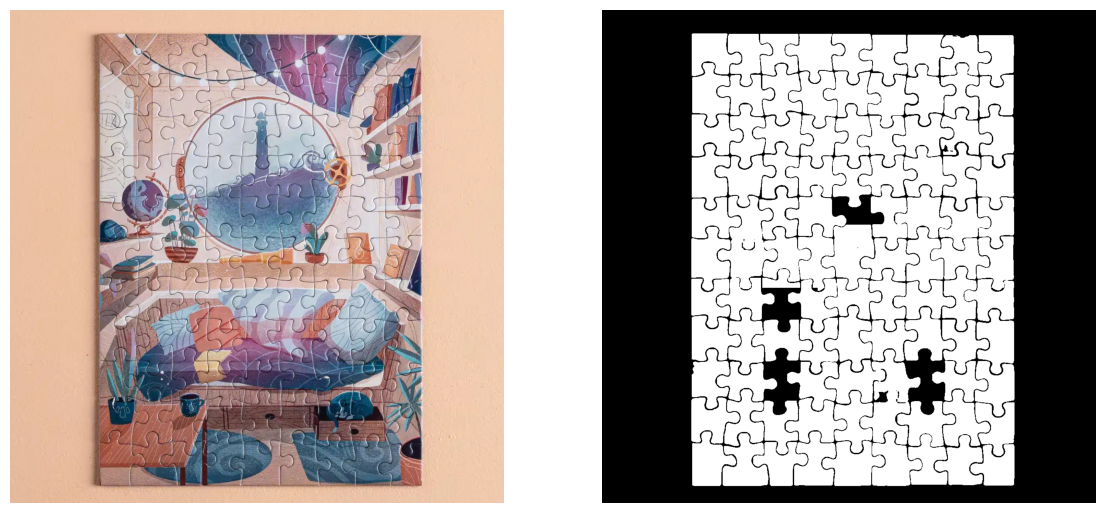

In [ ]:
plt.figure(figsize=(14, 10))
plt.subplot(121)
plt.imshow(cv2.imread(image_path)[:,:,::-1])  # Conversion BGR to RGB 
plt.axis('off')
plt.subplot(122)
plt.imshow(mask_result, cmap='gray')
plt.axis('off')
plt.show()